## Phytoplankton Dominance and Hypoxia in the NY Bight (Classifying HABs on spatial and temporal variables)
*E. Feusi*
*GTECH-331; Prof. Ni-Meister*

---

The main goal of this project is to determine whether nearshore sampling locations show stronger signs of hypoxia and phytoplankton-associated water-quality stress than offshore locations. Primarily, I'm concerned with answering the following:
 1. How does shoreline proximity vary among sampling observations?
 2. Do summer observations show lower bottom dissolved oxygen and higher chlorophyll concentrations than winter observations?
3. Are hypoxic observations more common at nearshore sites than offshore sites?
4. Is there a continuous relationship between shoreline distance and bottom dissolved oxygen?

*NOTE: Bloom proxies will be treated as general phytoplankton, as no dataset can accurately describe order from chlorophyll-a proxy alone.* 

---
In theory, shore-clustered cyanobacteria, present in hot summer conditions with greater incident sunlight (due to silicate solubility proportionte to temperature driving dominance in summer months) contribute more to hypoxic conditions than diatoms, which are further from shore typically and predominate in winter months.
Overall, I predict that summer observations closer to shore will tend to have higher chlorophyll values, which would co-occur with lower bottom dissolved oxygen per site, while winter observations will show a different mean weighted distance from show and fewer hypoxic events as a result.

---

**Datasets Used**:
* NYC Harbor Water Quality Monitoring Data (https://data.cityofnewyork.us/Environment/Harbor-Water-Quality/5uug-f49n)
* Exact fields intended for use from the harbor dataset:
    'Sampling Location',
    'Sample Date',
    'Top Sample Temperature (ºC)',
    'Winkler Method Bottom Dissolved Oxygen (mg/L)',
    "Top Active Chlorophyll 'A' (µg/L)",
    'Total Phosphorus (mg/L)',
    'Long',
    'Lat'
* NY boundary geometry: `State_Shoreline.shp`
* NJ boundary geometry: `NJ_State_Boundary.shp` #NOTE: DEPRECATED


---
## Methodology

This project uses both NYC harbor water-quality observations and shoreline boundary data from New York and New Jersey in order to derive a spatial measure of shoreline proximity for each sampling record. The workflow proceeds in five stages:

1. Load selected water-quality fields and simplify the original column names (and rename variables into shorter analysis-friendly names)
2. Convert sampling coordinates into a spatial point layer.
3. Load shoreline boundary data from NY and NJ
4. Compute the minimum distance from each sampling point to the nearest shoreline.
4. Define seasonal and hypoxia categories. 
5. Compare dissolved oxygen, chlorophyll-*a*, temperature, and hypoxia frequency across spatial and seasonal groupings using summary tables, plots, and a few simple statistical comparisons.

The project uses the following Python features required for the assignment:

- Using indexing / slicing to isolate relevant columns subsets / numericize
- **`numpy.where`** to define categorical variables such as season and hypoxia status
- **`groupby`** to generate monthly and seasonal summary statistics
- **`matplotlib`** to visualize spatial and temporal patterns

*(main response variable is bottom dissolved oxygen, and the main spatial predictor is distance from shore.)*

---
### Definitions and analysis framework


For consistency, I'll be following these definitions throughout:

- **Distance from shore**: the minimum planar distance from each sampling point to the nearest shoreline boundary, computed after projecting all spatial data to a projected coordinate reference system. Units: **meters (m)**.
- **Hypoxia**: bottom dissolved oxygen concentration less than **3.0 mg/L**.
- **Nearshore / offshore**: a relative shoreline-proximity grouping derived from the computed distance-to-shore variable.
- **Season**:
  - **Winter** = December, January, February
  - **Summer** = June, July, August
  - **Transition** = all remaining months


---
<h2 style="text-align: center;">Parameter Table</h2>

| Variable | Meaning | Units | Role in analysis |
|---|---|---:|---|
| `site` | Sampling location identifier | none | Site reference |
| `date` | Sampling date | date | Temporal grouping |
| `year` | Sampling year | year | Time breakdown |
| `month` | Sampling month | integer | Seasonal grouping |
| `lat` | Latitude of station | decimal degrees | Spatial geometry input |
| `lon` | Longitude of station | decimal degrees | Spatial geometry input |
| `chlor_a` | Chlorophyll-*a* concentration | typically µg/L | Proxy for phytoplankton biomass |
| `temp` | Water temperature | °C | Seasonal/environmental context |
| `do_bottom` | Bottom dissolved oxygen | mg/L | Main oxygen-response variable |
| `distance_to_shore_m` | Minimum shoreline distance | m | Main spatial predictor |
| `hypoxic` or `low_oxygen` | Indicator of hypoxia (`DO < 3.0 mg/L`) | binary | Event classification |
| `season` | Winter / Summer / Transition | categorical | Seasonal comparison |
| `shore_bin` | Nearshore / Offshore grouping | categorical | Spatial comparison |


In [4]:
# Important packages
import pandas as pd
import sys
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from pathlib import Path


In [5]:
# Setting file paths
# NOTE: NOAA CUST Shorelines ended up being massive, so instead, point-on-edge distance detection is just going to be 
# the method I'm sticking with for TIGER shapefiles...
water_fp = Path('NYS-Harbor-Data.csv')
ny_shore_fp = Path('State_Shoreline.shp')

nj_shore_fp = Path('New_Jersey.shp')


In [6]:
# Fields used from Harbor Dataset
use_cols = [
    'Sampling Location',
    'Sample Date',
    'Top Sample Temperature (ºC)',
    'Winkler Method Bottom Dissolved Oxygen (mg/L)',
    "Top Active Chlorophyll 'A' (µg/L)",
    'Total Phosphorus (mg/L)',
    'Long',
    'Lat'
]
df = pd.read_csv(water_fp, usecols=use_cols, low_memory=False)
df.columns = df.columns.str.strip()
# Cleaning Data (cont)...
# Renaming long field names, convert date
# This is just to spare my hands tbh
df = df.rename(columns={
    'Sampling Location': 'site',
    'Sample Date': 'date',
    'Top Sample Temperature (ºC)': 'temp_c',
    'Winkler Method Bottom Dissolved Oxygen (mg/L)': 'bottom_do_mg_l',
    "Top Active Chlorophyll 'A' (µg/L)": 'chl_a',
    'Total Phosphorus (mg/L)': 'phosphorus_mg_l',
    'Long': 'lon',
    'Lat': 'lat'
})

# Date Conversion
df['date'] = pd.to_datetime(df['date'])

df['month'] = df['date'].dt.month

# Convert numeric fields
for c in ['temp_c', 'bottom_do_mg_l', 'chl_a', 'phosphorus_mg_l', 'lon', 'lat']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df = df.dropna(subset=['temp_c', 'bottom_do_mg_l', 'phosphorus_mg_l', 'chl_a', 'lon', 'lat'])

df.head()

,site,date,temp_c,bottom_do_mg_l,phosphorus_mg_l,chl_a,lon,lat,month
0,N7,2019-08-13,23.3931,5.61,0.121,19.6,-74.053833,40.643833,8
1,E8,2020-03-03,4.2700,11.80,0.063,25.3,-73.783670,40.800500,3
5,K5,1996-04-18,10.6000,10.80,0.123,58.9,-74.258833,40.508833,4
8,H3,2011-06-28,22.2900,3.80,0.128,1.5,40.828980,-73.934040,6
13,H1,1991-07-24,26.2000,5.90,0.160,14.4,-73.923884,40.878055,7


The harbor data are still just tabular observations at this point, so to measure distance from shore, I turn the sampling coordinates into lat/lon points (according to CRS) and load the NY/NJ polygon layers as well. 

In [7]:
# Loading NY and NJ shoreline geometry, build harbor points, project both layers,
# and compute minimum distance from each sampling point to the shoreline...

ny_shore = gpd.read_file(ny_shore_fp)
nj_shore = gpd.read_file(nj_shore_fp)

# Reprojecting force espg 4326
ny_shore = ny_shore.to_crs("EPSG:4326")

nj_shore = nj_shore.to_crs("EPSG:4326")
#Combine shoreline layers
shore = gpd.GeoDataFrame(
    pd.concat([ny_shore, nj_shore], ignore_index=True),
    geometry="geometry",
    crs="EPSG:4326"
)


# harbor table --> point geometry
# NOTE: keeping the existing lat/lon handling here because of the input-file quirk
harbor_df = df.loc[
    df["lat"].between(-75, -73) & df["lon"].between(40, 41.5)
].copy()

gdf = gpd.GeoDataFrame(
    harbor_df,
    geometry=gpd.points_from_xy(harbor_df["lat"], harbor_df["lon"]),
    crs="EPSG:4326"
)

print(gdf[["site", "lon", "lat"]].head())
print("Longitude range:", gdf.geometry.x.min(), "to", gdf.geometry.x.max())
print("Latitude range:", gdf.geometry.y.min(), "to", gdf.geometry.y.max())

# Reproject to a planar CRS (so distances are in meters)
gdf = gdf.to_crs("EPSG:32618")
shore = shore.to_crs("EPSG:32618")

# Dissolve shoreline to simplify nearest-distance calculation
shore_union = shore.geometry.union_all() if hasattr(shore.geometry, "union_all") else shore.unary_union

# Compute minimum distance from each point to shoreline
gdf["distance_to_shore_m"] = gdf.geometry.distance(shore_union)

# intersecting points to distance 0 (nearshore)
gdf.loc[gdf.geometry.intersects(shore_union), "distance_to_shore_m"] = 0

# check
gdf[["site", "distance_to_shore_m"]].head()

   site       lon       lat
8    H3  40.82898 -73.93404
16  NC1  40.72410 -73.92656
21   N7  40.64383 -74.05317
51   J2  40.60933 -73.88567
52  GB1  40.60014 -74.01338
Longitude range: -74.25983 to -73.74697
Latitude range: 40.0 to 41.0


,site,distance_to_shore_m
8,H3,52.030909
16,NC1,0.000000
21,N7,1304.495435
51,J2,400.979708
52,GB1,158.400434


Now that the sampling records have been converted into mapped points and a shoreline-distance variable has been created these can be used to view the spatial table projected over the map.

Number of observations: 7649
Projected CRS: EPSG:32618


,site,date,lon,lat,temp_c,bottom_do_mg_l,chl_a,phosphorus_mg_l,distance_to_shore_m
8,H3,2011-06-28,40.82898,-73.93404,22.29,3.80,1.50,0.128,52.030909
16,NC1,2009-07-01,40.72410,-73.92656,22.04,4.97,77.00,0.312,0.000000
21,N7,2005-06-08,40.64383,-74.05317,19.02,7.76,2.44,0.134,1304.495435
51,J2,2006-06-20,40.60933,-73.88567,21.74,7.05,49.12,0.202,400.979708
52,GB1,2011-07-13,40.60014,-74.01338,22.96,6.54,2.70,0.150,158.400434


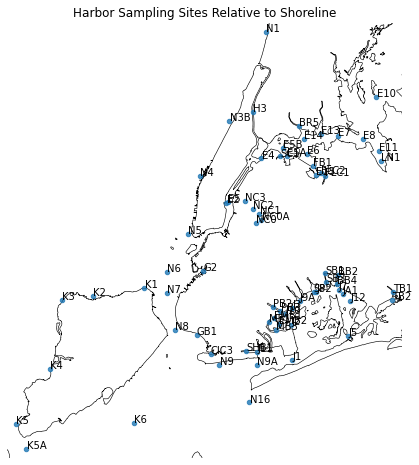

In [8]:
# Preview 
print("Number of observations:", len(gdf))
print("Projected CRS:", gdf.crs)
display(
    gdf[['site', 'date', 'lon', 'lat', 'temp_c', 'bottom_do_mg_l', 'chl_a', 'phosphorus_mg_l', 'distance_to_shore_m']].head()
)

# reduce to one point per site ...
sites_gdf = gdf.drop_duplicates(subset='site').copy()

# map of sampling sites and shoreline
fig, ax = plt.subplots(figsize=(8, 8))
shore.plot(ax=ax, color='none', edgecolor='black', linewidth=0.6)
sites_gdf.plot(ax=ax, color='tab:blue', markersize=20, alpha=0.8)

# Site labels
for x, y, label in zip(sites_gdf.geometry.x, sites_gdf.geometry.y, sites_gdf['site']):
    ax.text(
        x + 20, y + 20,
        str(label),
    )

# Set map extent to point bounds with a 1 km buffer
minx, miny, maxx, maxy = sites_gdf.total_bounds
buffer_m = 1000
ax.set_xlim(minx - buffer_m, maxx + buffer_m)
ax.set_ylim(miny - buffer_m, maxy + buffer_m)

ax.set_title('Harbor Sampling Sites Relative to Shoreline')
ax.set_axis_off()
plt.show()

First off, I'd like to see if there's any correlation between shoreline distance and total oxygenation, on average. There does appear to be a moderate positive correlation between DO and Distance from shoreline (with nearshore sites seeing lowered BDO on average).

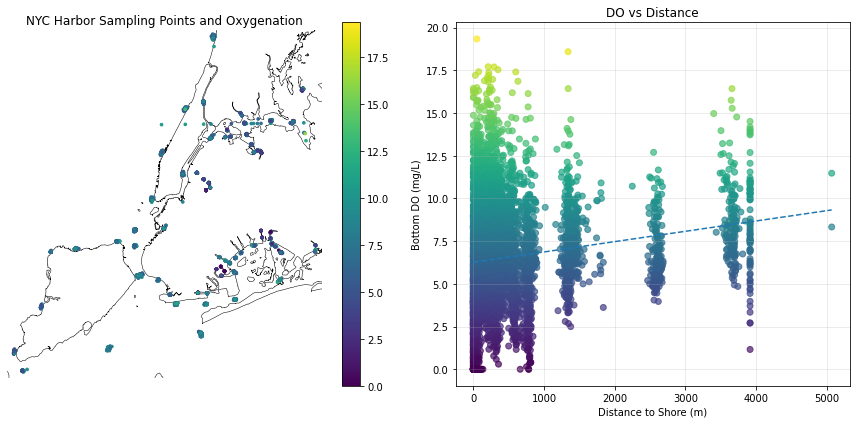

In [9]:
# map + side plot
fig, (ax_map, ax_plot) = plt.subplots(1, 2, figsize=(12, 6))

# --- LEFT: MAP ---
shore.plot(ax=ax_map, color='none', edgecolor='black', linewidth=0.5)
gdf.plot(ax=ax_map, column='bottom_do_mg_l', markersize=7, legend=True)

ax_map.set_title('NYC Harbor Sampling Points and Oxygenation')
ax_map.set_xlim(minx - buffer_m, maxx + buffer_m)
ax_map.set_ylim(miny - buffer_m, maxy + buffer_m)
ax_map.set_axis_off()

# --- RIGHT: DISTANCE vs DO ---
sc = ax_plot.scatter(
    gdf['distance_to_shore_m'],
    gdf['bottom_do_mg_l'],
    c=gdf['bottom_do_mg_l'],   # color by DO
    alpha=0.7
)

ax_plot.set_xlabel('Distance to Shore (m)')
ax_plot.set_ylabel('Bottom DO (mg/L)')
ax_plot.set_title('DO vs Distance')
ax_plot.grid(alpha=0.3)

# trendline
x = gdf['distance_to_shore_m']
y = gdf['bottom_do_mg_l']
mask = x.notna() & y.notna()
m, b = np.polyfit(x[mask], y[mask], 1)
x_line = np.linspace(x[mask].min(), x[mask].max(), 200)
ax_plot.plot(x_line, m*x_line + b, linestyle='--')



plt.tight_layout()
plt.show()


With the shoreline-distance field now created, next I'll be defining some categorical variables for later comparison: 
- `Season`: winter, summer, or transition
- `Hypoxia indication`: bottom dissolved oxygen below 3.0 mg/L
- `Shoreline group`: nearshore or offshore (defined using the median shoreline-distance)

In [10]:
# Defining season, hypoxia, and nearshore/offshore categories...

gdf['season'] = np.where( # obs per season
    gdf['month'].isin([12, 1, 2]), 'winter',
    np.where(gdf['month'].isin([6, 7, 8]), 'summer', 'transition')
)
gdf['low_oxygen_3mg'] = np.where(gdf['bottom_do_mg_l'] < 3.0, 1, 0)

# med. distance for nearshore v. offshore
dist_thresh = gdf['distance_to_shore_m'].median()
gdf['shore_bin'] = np.where(
    gdf['distance_to_shore_m'] < dist_thresh,
    'nearshore',
    'offshore'
)
display(gdf[['season', 'low_oxygen_3mg', 'shore_bin', 'distance_to_shore_m']].head())
print("Median shoreline-distance threshold (m):", round(dist_thresh, 2))

,season,low_oxygen_3mg,shore_bin,distance_to_shore_m
8,summer,0,nearshore,52.030909
16,summer,0,nearshore,0.000000
21,summer,0,offshore,1304.495435
51,summer,0,offshore,400.979708
52,summer,0,nearshore,158.400434


Median shoreline-distance threshold (m): 221.7


<h2 style="text-align: center;"> Derived Variables </h2>

| Variable | Meaning | Type |
|---|---|---|
| `distance_to_shore_m` | Minimum distance from sampling point to shoreline | meters |
| `season` | Winter / Summer / Transition | categorical |
| `low_oxygen_3mg` | Indicator for bottom dissolved oxygen below 3.0 mg/L | bool |
| `shore_bin` | Nearshore / Offshore category based on median distance | categorical |

I'm mainly concerned about the comparison between summer and winter, so now I will be looking at these two seasonal regiemes as well (`season_space`) -- It appears that mean bottom oxygenation significantly raises during winter months, with moderate increases across both summer and winter in offshore BDO compared to nearshore.

In [11]:
# focus only on winter and summer
subset = gdf[gdf['season'].isin(['winter', 'transition', 'summer'])]
season_space = subset.groupby(['season', 'shore_bin'], as_index=False).agg(
    mean_chl=('chl_a', 'mean'),
    mean_temp=('temp_c', 'mean'),
    mean_bottom_do=('bottom_do_mg_l', 'mean'),
    mean_phosphorus=('phosphorus_mg_l', 'mean'),
    low_oxygen_freq=('low_oxygen_3mg', 'mean'),
    mean_distance_m=('distance_to_shore_m', 'mean')
)

season_space

,season,shore_bin,mean_chl,mean_temp,mean_bottom_do,mean_phosphorus,low_oxygen_freq,mean_distance_m
0,summer,nearshore,19.509673,22.924885,5.134256,0.286371,0.135725,95.575362
1,summer,offshore,17.368543,22.712894,5.924638,0.214505,0.075758,822.218248
2,transition,nearshore,13.635914,18.499384,6.368233,0.219214,0.081395,96.213935
3,transition,offshore,11.924571,18.316871,7.122778,0.170468,0.013418,725.651284
4,winter,nearshore,10.664777,5.562442,9.976709,0.171310,0.004246,95.043424
5,winter,offshore,12.976504,5.213828,10.472188,0.135084,0.000000,986.123461


Here is the same plot as prior, but now delineated by seasonal variables. Notably, winter trends towards a higher DO, especially when closer to shore.

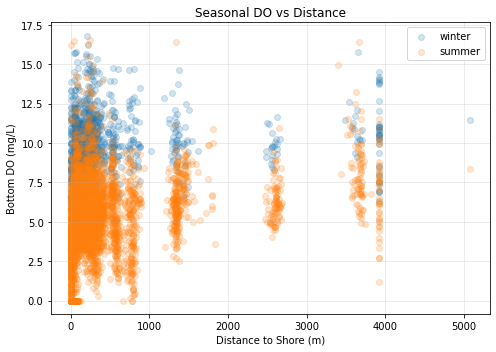

In [12]:
# seasonal scatterplot: winter and summer only
fig, ax = plt.subplots(figsize=(7, 5))

for season in ['winter', 'summer']:
    d = gdf[gdf['season'] == season]
    ax.scatter(
        d['distance_to_shore_m'],
        d['bottom_do_mg_l'],
        alpha=0.2,
        label=season
    )

ax.set_xlabel('Distance to Shore (m)')
ax.set_ylabel('Bottom DO (mg/L)')
ax.set_title('Seasonal DO vs Distance')
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

I suspect that this correlation is caused by nearshore conditions being much more sensitive to eutrophic conditions due to decreased water column volume, but more importantly, their massive input of nutritive pollutants (mainly phosphourous as a major limiting nutrient) through runoff and sewage. Unsurprisingly, nearshore sites saw a much greater variance in average phosphorous pollution. Some of the worst sites included BB4, NC0, and BB2 --  two of which are located on Jamaica bay, and the third in Newton creek (whose sites' consistenly ranks high for Phosphate pollution overall).

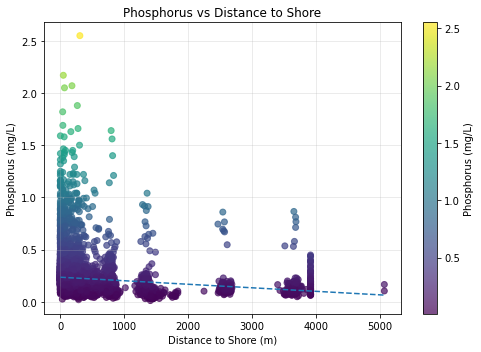

,site,phosphorus_mg_l
1,BB4,0.458350
56,NC0,0.396654
0,BB2,0.373688
63,SB1,0.369818
32,J7,0.365882
58,NC1,0.354572
67,SP2,0.329818
28,J12,0.329552
59,NC2,0.329044
64,SB3,0.321300


In [22]:
fig, ax = plt.subplots(figsize=(7, 5))

sc = ax.scatter(
    gdf['distance_to_shore_m'],
    gdf['phosphorus_mg_l'],
    c=gdf['phosphorus_mg_l'],
    alpha=0.7
)

plt.colorbar(sc, ax=ax, label='Phosphorus (mg/L)')

# trendline
x = gdf['distance_to_shore_m']
y = gdf['phosphorus_mg_l']
mask = x.notna() & y.notna()

m, b = np.polyfit(x[mask], y[mask], 1)
x_line = np.linspace(x[mask].min(), x[mask].max(), 200)
ax.plot(x_line, m*x_line + b, linestyle='--')

ax.set_title('Phosphorus vs Distance to Shore')
ax.set_xlabel('Distance to Shore (m)')
ax.set_ylabel('Phosphorus (mg/L)')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

gdf.groupby('site', as_index=False)['phosphorus_mg_l'] \
    .mean() \
    .sort_values('phosphorus_mg_l', ascending=False) \
    .head(10)

Now to compare the main variables of interest -- chlorophyll, temperature, and bottom dissolved oxygen -- across the nearshore/offshore and winter/summer categories. As expected, bottom DO seems to rise in the winter, strongly inversely correlated with temperature. What is sort of interesting is that offshore Chlorophyll seasonality is mediated a bit more than nearshore, while transitional offshore periods see the greatest drop (likely due to the months march and april having the greatest average sea ice extent)

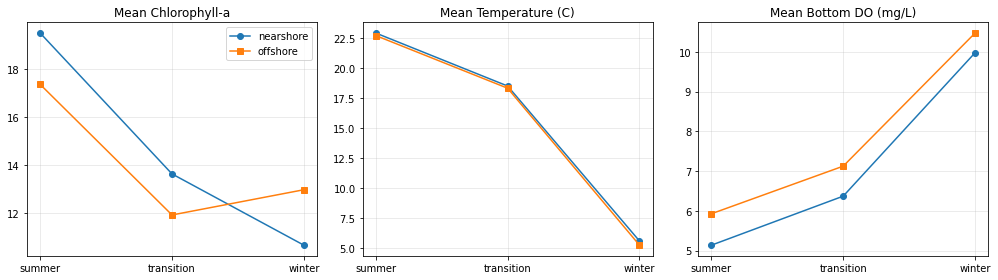

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True)

vars_to_plot = [
    ('mean_chl', 'Mean Chlorophyll-a'),
    ('mean_temp', 'Mean Temperature (C)'),
    ('mean_bottom_do', 'Mean Bottom DO (mg/L)')
]

for ax, (v, title) in zip(axes, vars_to_plot): #[HERE!!!]
    for region, marker in [('nearshore', 'o'), ('offshore', 's')]:
        d = season_space[season_space['shore_bin'] == region]
        ax.plot(d['season'], d[v], marker=marker, label=region)
    ax.set_title(title)
    ax.grid(alpha=0.3)

axes[0].legend()
plt.tight_layout() #keeps on clipping :/
plt.show()

Finally, I'd like to check out how many low-O2 observations occur in each seasonal and spatial category, and compare overall oxygenation per season and parameter. 

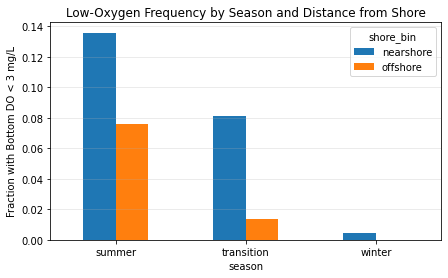

In [14]:
pivot_lo = season_space.pivot(index='season', columns='shore_bin', values='low_oxygen_freq')
# pandas daaframe pivot changes data from a long to wide format for comp)

pivot_lo.plot(kind='bar', figsize=(7, 4))
plt.ylabel('Fraction with Bottom DO < 3 mg/L')
plt.title('Low-Oxygen Frequency by Season and Distance from Shore')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

*(Note the ridiculously low level of hyoxic observations in winter)*

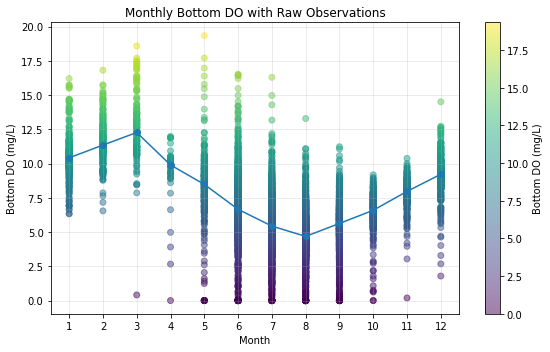

In [19]:
# monthly summary for DO
monthly_do = gdf.groupby('month', as_index=False).agg(
    median_bottom_do=('bottom_do_mg_l', 'median')
)

fig, ax = plt.subplots(figsize=(8, 5))

# raw points
sc = ax.scatter(
    gdf['month'],
    gdf['bottom_do_mg_l'],
    c=gdf['bottom_do_mg_l'],
    alpha=0.5
)

# overlays
ax.plot(monthly_do['month'], monthly_do['median_bottom_do'], marker='o', linestyle='-', label='Median DO')

plt.colorbar(sc, ax=ax, label='Bottom DO (mg/L)')

ax.set_title('Monthly Bottom DO with Raw Observations')
ax.set_xlabel('Month')
ax.set_ylabel('Bottom DO (mg/L)')
ax.set_xticks(range(1, 13))
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Now, to get some basic aggregative stats across parameters:

In [23]:
stats = gdf.groupby('season').agg(
    mean_bottom_do=('bottom_do_mg_l', 'mean'),
    std_bottom_do=('bottom_do_mg_l', 'std'),
    hypoxia_freq=('low_oxygen_3mg', 'mean'),
    n=('bottom_do_mg_l', 'count')
).reset_index()

# convert hypoxia to %
stats['hypoxia_freq'] = stats['hypoxia_freq'] * 100

stats

,season,mean_bottom_do,std_bottom_do,hypoxia_freq,n
0,summer,5.527812,2.244584,10.586517,4109
1,transition,6.742112,2.610221,4.771216,2557
2,winter,10.234781,1.846892,0.203459,983


### Summary

- **Summer**
  - Mean bottom DO: **5.53 mg/L**
  - Standard deviation: **2.244 mg/L**
  - Hypoxia frequency: **10.59%**
  - Sample size: **n = 4109**

- **Transition months**
  - Mean bottom DO: **6.74 mg/L**
  - Standard deviation: **2.61 mg/L**
  - Hypoxia frequency: **4.77%**
  - Sample size: **n = 2557**

- **Winter**
  - Mean bottom DO: **10.527 mg/L**
  - Standard deviation: **1.85 mg/L**
  - Hypoxia frequency: **1.8%**
  - Sample size: **n = 983**


Overall, the summer observations appear to be more strongly associated with higher chlorophyll values and more frequent low-oxygen conditions than the winter observations. Nearshore points also appear more likely to show reduced bottom dissolved oxygen than offshore points. 

This broadly supports the idea that warm-season nearshore phytoplankton-rich conditions correspond more closely with hypoxic events than cooler, farther-from-shore conditions. At the same time, chlorophyll-a is only being used here as a general phytoplankton proxy, so these patterns should not be read as direct evidence of cyanobacteria or diatom dominance by themselves...



##### Additional quantitative notes

- The increase in hypoxia frequency from ~0% (winter) to ~11% (summer) surprisingly represents nearly an order-of-magnitude seasonal shift in low-oxygen risk.
- Large summer standard deviation (≈2.05 mg/L) indicate heterogeneous conditions which are consistent with localized stratification (clustered around shoreline).

---

#### References

- Diaz, R. J., & Rosenberg, R. (2008). Spreading dead zones and consequences for marine ecosystems. *Science*, 321(5891), 926–929.
- Redfield, A. C., Ketchum, B. H., & Richards, F. A. (1963). The influence of organisms on the composition of seawater. *The Sea*, 2, 26–77.
- Tréguer, P., Nelson, D. M., Van Bennekom, A. J., DeMaster, D. J., Leynaert, A., & Quéguiner, B. (1995). The silica balance in the world ocean. *Science*, 268(5209), 375–379.
